# Skenario 3: Multimodal Fusion (S3)

**Arsitektur:** Intermediate Fusion — TabularBranch (MLP) + ImageBranch (DenseNet-121) → Concatenate → Fusion Head  
Model diambil dari `src/models/architectures.py` kelas `MultimodalFusion`.

| | S3 |
|---|---|
| **Input** | Tabular + Gambar |
| **Output** | Biner (Normal/Abnormal) |
| **Loss** | BCEWithLogitsLoss (1 output, weighted) |
| **Metrik** | Accuracy, Precision, Recall, F1, AUC-ROC |

In [1]:
import sys
sys.path.insert(0, r"D:\TA\nih-multimodal")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.amp import autocast, GradScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    confusion_matrix, roc_curve, accuracy_score,
    average_precision_score
)

from configs.config import cfg
from src.models.architectures import MultimodalFusion
from src.data.dataset import create_dataloaders, compute_pos_weights

torch.manual_seed(cfg.train.seed)
np.random.seed(cfg.train.seed)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR   = cfg.paths.figures_dir
CKPT_DIR   = cfg.paths.checkpoint_dir
TABLES_DIR = cfg.paths.project_root / "results" / "tables"
for d in [SAVE_DIR, CKPT_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LABEL_NAMES = list(cfg.data.label_names)
ACCUM_STEPS = cfg.train.gradient_accumulation_steps

print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Labels  : {len(LABEL_NAMES)} penyakit")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3060 Laptop GPU
VRAM    : 6.4 GB
Labels  : 14 penyakit


## 1. Load Dataset

In [ ]:
train_loader, val_loader, test_loader, scaler, pos_weights = create_dataloaders(
    batch_size=cfg.train.batch_size
)
pos_weights = pos_weights.to(DEVICE)

print(f"Train : {len(train_loader.dataset):,} | Val : {len(val_loader.dataset):,} | Test : {len(test_loader.dataset):,}")
print(f"pos_weight (binary) : {pos_weights.item():.3f}")

---
# Skenario 3: Multimodal Fusion — Klasifikasi Biner

## 2. Model S3

In [ ]:
model_s3 = MultimodalFusion(num_classes=1).to(DEVICE)
criterion_s3 = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
scaler_amp_s3 = GradScaler('cuda', enabled=cfg.train.use_amp)

optimizer_s3 = torch.optim.AdamW([
    {"params": model_s3.tabular_branch.parameters(), "lr": cfg.train.lr_tabular},
    {"params": model_s3.image_branch.parameters(),   "lr": cfg.train.lr_backbone},
    {"params": model_s3.fusion.parameters(),         "lr": cfg.train.lr_fusion},
    {"params": model_s3.classifier.parameters(),     "lr": cfg.train.lr_fusion},
], weight_decay=cfg.train.weight_decay)

scheduler_s3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_s3, mode="max", patience=cfg.train.scheduler_patience,
    factor=cfg.train.scheduler_factor,
)

total = sum(p.numel() for p in model_s3.parameters())
trainable = sum(p.numel() for p in model_s3.parameters() if p.requires_grad)
print(f"MultimodalFusion S3 | Total: {total:,} | Trainable: {trainable:,}")

## 3. Training Loop S3

In [4]:
def train_epoch_mm(model, loader, criterion, optimizer, scaler_amp, device,
                   accum_steps, label_key="label_binary"):
    model.train()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader):
        images  = batch["image"].to(device, non_blocking=True)
        tabular = batch["tabular"].to(device, non_blocking=True)
        labels  = batch[label_key].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images, tabular=tabular)
            if label_key == "label_binary":
                logits = logits.squeeze(1)
            loss = criterion(logits, labels) / accum_steps

        scaler_amp.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler_amp.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps * len(labels)
        n += len(labels)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    if label_key == "label_binary":
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = roc_auc_score(all_labels, all_probs, average="macro")
    return total_loss / n, auc


@torch.no_grad()
def evaluate_mm(model, loader, criterion, device, label_key="label_binary"):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_labels = [], []

    for batch in loader:
        images  = batch["image"].to(device, non_blocking=True)
        tabular = batch["tabular"].to(device, non_blocking=True)
        labels  = batch[label_key].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg.train.use_amp):
            logits = model(image=images, tabular=tabular)
            if label_key == "label_binary":
                logits = logits.squeeze(1)
            loss = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        n += len(labels)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    if label_key == "label_binary":
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = roc_auc_score(all_labels, all_probs, average="macro")
    return total_loss / n, auc, all_probs, all_labels


# ── Training S3 ──
CKPT_S3  = CKPT_DIR / "model_s3_multimodal_binary.pt"
history_s3 = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": []}
best_val_auc_s3, patience_counter = 0.0, 0
t0 = time.time()

print(f"{'Epoch':>5} {'Train Loss':>12} {'Train AUC':>10} {'Val Loss':>10} {'Val AUC':>9} {'Time':>7}")
print("-" * 60)

for epoch in range(1, cfg.train.num_epochs + 1):
    ep_start = time.time()
    train_loss, train_auc = train_epoch_mm(
        model_s3, train_loader, criterion_s3, optimizer_s3,
        scaler_amp_s3, DEVICE, ACCUM_STEPS, label_key="label_binary"
    )
    val_loss, val_auc, _, _ = evaluate_mm(
        model_s3, val_loader, criterion_s3, DEVICE, label_key="label_binary"
    )
    history_s3["train_loss"].append(train_loss)
    history_s3["val_loss"].append(val_loss)
    history_s3["train_auc"].append(train_auc)
    history_s3["val_auc"].append(val_auc)
    scheduler_s3.step(val_auc)
    ep_time = time.time() - ep_start

    flag = ""
    if val_auc > best_val_auc_s3:
        best_val_auc_s3 = val_auc
        torch.save(model_s3.state_dict(), CKPT_S3)
        patience_counter = 0
        flag = " ✓"
    else:
        patience_counter += 1

    print(f"{epoch:>5} {train_loss:>12.4f} {train_auc:>10.4f} "
          f"{val_loss:>10.4f} {val_auc:>9.4f} {ep_time:>6.1f}s{flag}")

    if patience_counter >= cfg.train.early_stop_patience:
        print(f"\nEarly stopping di epoch {epoch}")
        break

print(f"\nS3 selesai {(time.time()-t0)/60:.1f} menit | Best Val AUC: {best_val_auc_s3:.4f}")

Epoch   Train Loss  Train AUC   Val Loss   Val AUC    Time
------------------------------------------------------------
    1       0.6839     0.7604     0.6582    0.7833  699.2s ✓
    2       0.6758     0.7670     0.6533    0.7886  700.0s ✓
    3       0.6699     0.7718     0.6534    0.7879  671.0s
    4       0.6693     0.7723     0.6502    0.7897  664.3s ✓
    5       0.6695     0.7726     0.6572    0.7845  648.0s
    6       0.6681     0.7736     0.6509    0.7895  639.7s
    7       0.6663     0.7748     0.6529    0.7866  645.3s
    8       0.6662     0.7753     0.6516    0.7885  661.9s
    9       0.6623     0.7784     0.6492    0.7893  655.8s
   10       0.6620     0.7786     0.6545    0.7892  671.8s
   11       0.6606     0.7801     0.6520    0.7862  677.2s

Early stopping di epoch 11

S3 selesai 122.2 menit | Best Val AUC: 0.7897


## 4. Evaluasi S3

In [5]:
model_s3.load_state_dict(torch.load(CKPT_S3, map_location=DEVICE))
_, _, test_probs_s3, test_labels_s3 = evaluate_mm(
    model_s3, test_loader, criterion_s3, DEVICE, label_key="label_binary"
)
test_preds_s3 = (test_probs_s3 >= 0.5).astype(int)

acc_s3  = accuracy_score(test_labels_s3, test_preds_s3)
f1_s3   = f1_score(test_labels_s3, test_preds_s3, average="binary")
f1m_s3  = f1_score(test_labels_s3, test_preds_s3, average="macro")
auc_s3  = roc_auc_score(test_labels_s3, test_probs_s3)

print("=" * 55)
print("HASIL EVALUASI SKENARIO 3: MULTIMODAL FUSION BINER")
print("=" * 55)
print(f"Accuracy       : {acc_s3:.4f}")
print(f"F1-Score (bin) : {f1_s3:.4f}")
print(f"F1-Score (mac) : {f1m_s3:.4f}")
print(f"AUC-ROC        : {auc_s3:.4f}")
print()
print(classification_report(test_labels_s3, test_preds_s3, target_names=["Normal", "Abnormal"]))

C:\Users\ASUS\AppData\Local\Temp\ipykernel_27504\945812135.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_s3.load_state_dict(torch.load(CKPT_S3, map_location=DEVI

HASIL EVALUASI SKENARIO 3: MULTIMODAL FUSION BINER
Accuracy       : 0.7328
F1-Score (bin) : 0.8036
F1-Score (mac) : 0.6931
AUC-ROC        : 0.7449

              precision    recall  f1-score   support

      Normal       0.73      0.48      0.58      9861
    Abnormal       0.73      0.89      0.80     15735

    accuracy                           0.73     25596
   macro avg       0.73      0.69      0.69     25596
weighted avg       0.73      0.73      0.72     25596



## 5. ROC Curve S1 vs S2 vs S3

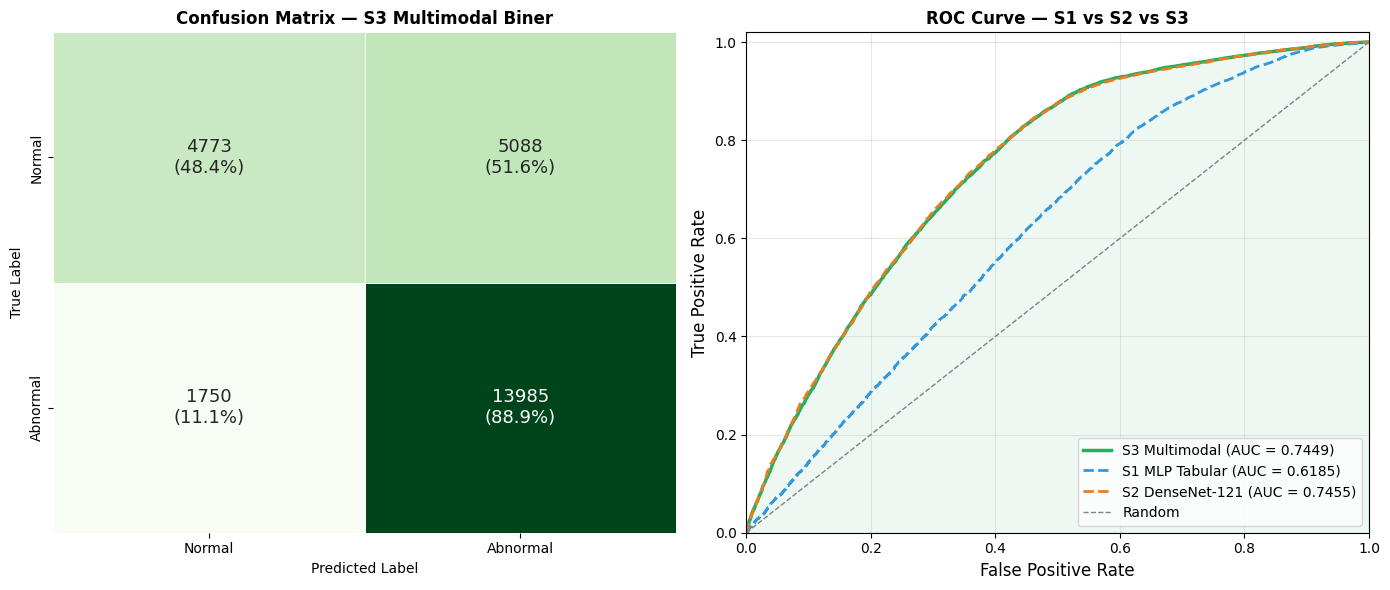

Disimpan → results/figures/s3_confusion_roc.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix S3
cm_s3  = confusion_matrix(test_labels_s3, test_preds_s3)
cm_pct = cm_s3.astype(float) / cm_s3.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f"{cm_s3[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(cm_s3, annot=annot, fmt="", cmap="Greens", ax=axes[0],
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"],
            linewidths=0.5, cbar=False, annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix — S3 Multimodal Biner", fontweight="bold")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# ROC Curve perbandingan S1, S2, S3
fpr_s3, tpr_s3, _ = roc_curve(test_labels_s3, test_probs_s3)
axes[1].plot(fpr_s3, tpr_s3, color="#27ae60", linewidth=2.5,
             label=f"S3 Multimodal (AUC = {auc_s3:.4f})")

for fname, color, label in [
    ("predictions_s1.csv", "#3498db", "S1 MLP Tabular"),
    ("predictions_s2.csv", "#e67e22", "S2 DenseNet-121"),
]:
    p = TABLES_DIR / fname
    if p.exists():
        df_ = pd.read_csv(p)
        prob_col = [c for c in df_.columns if c.startswith("prob_")][0]
        fpr_, tpr_, _ = roc_curve(df_["true_label"], df_[prob_col])
        auc_ = roc_auc_score(df_["true_label"], df_[prob_col])
        axes[1].plot(fpr_, tpr_, color=color, linewidth=2, linestyle="--",
                     label=f"{label} (AUC = {auc_:.4f})")

axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Random")
axes[1].fill_between(fpr_s3, tpr_s3, alpha=0.08, color="#27ae60")
axes[1].set_xlabel("False Positive Rate", fontsize=12)
axes[1].set_ylabel("True Positive Rate", fontsize=12)
axes[1].set_title("ROC Curve — S1 vs S2 vs S3", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig(SAVE_DIR / "s3_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "true_label": test_labels_s3.astype(int),
    "prob_s3"   : test_probs_s3,
    "pred_s3"   : test_preds_s3,
}).to_csv(TABLES_DIR / "predictions_s3.csv", index=False)
print("Disimpan → results/figures/s3_confusion_roc.png")

## 10. Simpan Hasil & Tabel Perbandingan S1–S3

In [ ]:
# Simpan hasil S3
pd.DataFrame([{
    "Skenario": "S3", "Model": "Multimodal Fusion",
    "Input": "Tabular + Gambar", "Output": "Biner",
    "Accuracy": round(acc_s3, 4), "F1 (Binary)": round(f1_s3, 4),
    "F1 (Macro)": round(f1m_s3, 4), "AUC-ROC": round(auc_s3, 4),
}]).to_csv(TABLES_DIR / "results_s3.csv", index=False)

# Tabel ringkasan S1–S3
rows_summary = []
for f in ["results_s1.csv", "results_s2.csv", "results_s3.csv"]:
    p = TABLES_DIR / f
    if p.exists():
        rows_summary.append(pd.read_csv(p))
if rows_summary:
    df_summary = pd.concat(rows_summary, ignore_index=True)
    df_summary.to_csv(TABLES_DIR / "results_summary.csv", index=False)
    cols = [c for c in ["Skenario", "Model", "Accuracy", "F1 (Binary)", "F1 (Macro)", "AUC-ROC"] if c in df_summary.columns]
    print("\n=== PERBANDINGAN S1 vs S2 vs S3 ===")
    print(df_summary[cols].to_string(index=False))

print("\nSemua hasil tersimpan di results/tables/")

## 11. Learning Curves S3

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep = range(1, len(history_s3["train_loss"]) + 1)

axes[0].plot(ep, history_s3["train_loss"], color="#27ae60", linewidth=2, label="Train")
axes[0].plot(ep, history_s3["val_loss"],   color="#27ae60", linewidth=2, linestyle="--", label="Val")
axes[0].set_title("S3 — Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

best_ep = int(np.argmax(history_s3["val_auc"])) + 1
axes[1].plot(ep, history_s3["train_auc"], color="#27ae60", linewidth=2, label="Train")
axes[1].plot(ep, history_s3["val_auc"],   color="#27ae60", linewidth=2, linestyle="--", label="Val")
axes[1].axvline(best_ep, color="gray", linestyle=":", alpha=0.7, label=f"Best ep {best_ep}")
axes[1].set_title("S3 — AUC-ROC", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("AUC-ROC")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Skenario 3: Multimodal Fusion — Learning Curves", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "s3_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan → results/figures/s3_training_curves.png")

## Ringkasan

**Artefak yang dihasilkan (scope proposal):**
- `results/checkpoints/model_s3_multimodal_binary.pt` — model S3 terbaik (untuk SHAP + Grad-CAM)
- `results/figures/s3_confusion_roc.png` — confusion matrix + ROC perbandingan S1 vs S2 vs S3
- `results/figures/s3_training_curves.png` — learning curves S3
- `results/tables/results_summary.csv` — perbandingan S1–S3 (Accuracy, F1, AUC-ROC)
- `results/tables/predictions_s3.csv` — prediksi S3 untuk analisis XAI

> **Langkah selanjutnya:** Model S3 digunakan di Notebook 06 untuk analisis dual XAI — SHAP KernelExplainer (branch tabular) dan Grad-CAM pada denseblock4 (branch gambar).

---
*Eksplorasi multi-label (di luar scope proposal) tersimpan di bagian bawah notebook ini.*